# Detection de Fraude par Carte de Credit
## Classification Robuste et Analyse de Decision en Environnement Critique

**Objectif**: Concevoir un systeme de classification robuste capable de gerer un desequilibre extreme tout en garantissant des probabilites de prediction fiables.

### Table des matieres
1. [Etape 1: Analyse Exploratoire et Preparation (EDA)](#step1)
2. [Etape 2: Developpement des Modeles](#step2)
3. [Etape 3: Evaluation et Calibration](#step3)
4. [Etape 4: Interpretabilite (SHAP)](#step4)

---

In [59]:
# Installation des dependances necessaires (decommenter si besoin)
# %pip install -q pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost optuna shap statsmodels

In [60]:
# =============================================================================
# IMPORTS
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, 
    precision_recall_curve, average_precision_score,
    matthews_corrcoef, roc_auc_score, roc_curve,
    precision_score, recall_score, brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Imbalanced learning
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import NearMiss

# XGBoost et Optuna
import xgboost as xgb
import optuna

# VIF pour la colinearite
from statsmodels.stats.outliers_influence import variance_inflation_factor

# SHAP pour l'interpretabilite
import shap

# Style des graphiques
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette('husl')

print("Toutes les bibliotheques sont importees avec succes!")

Toutes les bibliotheques sont importees avec succes!


---
<a id='step1'></a>
# ETAPE 1: Analyse Exploratoire et Preparation (EDA)

Dans cette etape, nous allons:
- Charger et explorer le dataset
- Analyser la distribution des classes (desequilibre)
- Analyser la colinearite (matrice de correlation + VIF)
- Comparer les techniques de traitement du desequilibre

## 1.1 Chargement des Donnees

In [61]:
# Charger le dataset
df = pd.read_csv('creditcard.csv')

print("=" * 70)
print("CHARGEMENT DU DATASET")
print("=" * 70)
print(f"\nShape du dataset: {df.shape}")
print(f"Nombre de transactions: {len(df):,}")
print(f"Nombre de features: {df.shape[1] - 1}")

df.head()

CHARGEMENT DU DATASET

Shape du dataset: (284807, 31)
Nombre de transactions: 284,807
Nombre de features: 30


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [62]:
# Informations sur le dataset
print("\n" + "=" * 70)
print("INFORMATIONS SUR LE DATASET")
print("=" * 70)

print("\nTypes de donnees:")
print(df.dtypes.value_counts())

print(f"\nValeurs manquantes: {df.isnull().sum().sum()}")

print("\nStatistiques descriptives:")
df.describe().round(2)


INFORMATIONS SUR LE DATASET

Types de donnees:
float64    30
int64       1
Name: count, dtype: int64

Valeurs manquantes: 0

Statistiques descriptives:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,...,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00
mean,94813.86,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,...,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,88.35,0.00
std,47488.15,1.96,1.65,1.52,1.42,1.38,1.33,1.24,1.19,1.10,...,0.73,0.73,0.62,0.61,0.52,0.48,0.40,0.33,250.12,0.04
min,0.00,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,...,-34.83,-10.93,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00
25%,54201.50,-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,...,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.60,0.00
50%,84692.00,0.02,0.07,0.18,-0.02,-0.05,-0.27,0.04,0.02,-0.05,...,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.00,0.00
75%,139320.50,1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,...,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.16,0.00
max,172792.00,2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,...,27.20,10.50,22.53,4.58,7.52,3.52,31.61,33.85,25691.16,1.00


## 1.2 Analyse du Desequilibre des Classes

In [63]:
# Distribution de la variable cible
print("=" * 70)
print("ANALYSE DU DESEQUILIBRE DES CLASSES")
print("=" * 70)

class_counts = df['Class'].value_counts()
class_percentages = df['Class'].value_counts(normalize=True) * 100

print(f"\nClasse 0 (Non-Fraude): {class_counts[0]:,} transactions ({class_percentages[0]:.4f}%)")
print(f"Classe 1 (Fraude):     {class_counts[1]:,} transactions ({class_percentages[1]:.4f}%)")
print(f"\nRatio de desequilibre: 1:{class_counts[0]/class_counts[1]:.0f}")
print("\n>>> Le dataset est EXTREMEMENT desequilibre!")

ANALYSE DU DESEQUILIBRE DES CLASSES

Classe 0 (Non-Fraude): 284,315 transactions (99.8273%)
Classe 1 (Fraude):     492 transactions (0.1727%)

Ratio de desequilibre: 1:578

>>> Le dataset est EXTREMEMENT desequilibre!


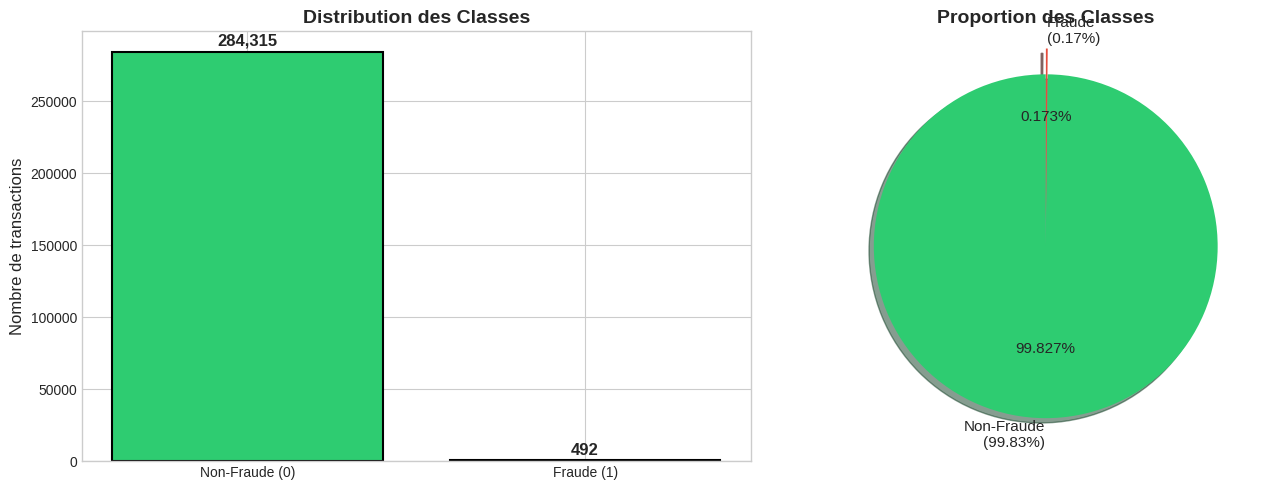


[Figure sauvegardee: fig1_class_distribution.png]


In [64]:
# Visualisation du desequilibre
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Non-Fraude (0)', 'Fraude (1)'], class_counts.values, 
                   color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Nombre de transactions', fontsize=12)
axes[0].set_title('Distribution des Classes', fontsize=14, fontweight='bold')
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000, 
                 f'{count:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Non-Fraude\n(99.83%)', 'Fraude\n(0.17%)'], 
            autopct='%1.3f%%', colors=colors, explode=[0, 0.15], 
            shadow=True, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proportion des Classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[Figure sauvegardee: fig1_class_distribution.png]")

## 1.3 Analyse des Features Time et Amount

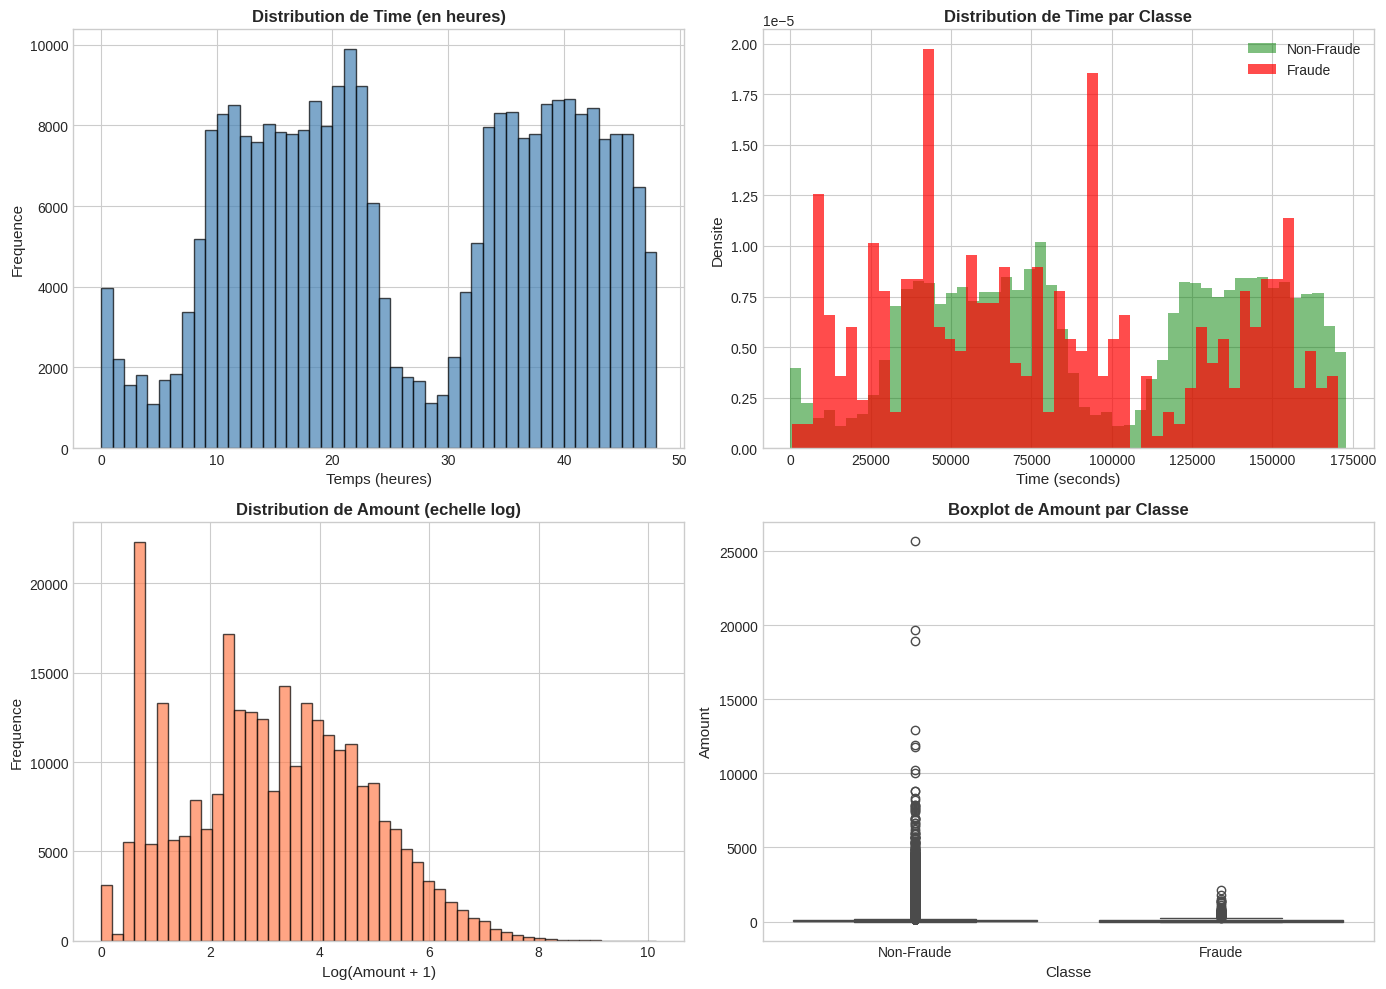

In [65]:
# Distribution de Time et Amount
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Time - Distribution globale
axes[0, 0].hist(df['Time'] / 3600, bins=48, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Temps (heures)', fontsize=11)
axes[0, 0].set_ylabel('Frequence', fontsize=11)
axes[0, 0].set_title('Distribution de Time (en heures)', fontweight='bold')

# Time - Par classe
df[df['Class'] == 0]['Time'].hist(bins=50, ax=axes[0, 1], alpha=0.5, 
                                   label='Non-Fraude', color='green', density=True)
df[df['Class'] == 1]['Time'].hist(bins=50, ax=axes[0, 1], alpha=0.7, 
                                   label='Fraude', color='red', density=True)
axes[0, 1].set_xlabel('Time (seconds)', fontsize=11)
axes[0, 1].set_ylabel('Densite', fontsize=11)
axes[0, 1].set_title('Distribution de Time par Classe', fontweight='bold')
axes[0, 1].legend()

# Amount - Distribution (log scale)
axes[1, 0].hist(np.log1p(df['Amount']), bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Log(Amount + 1)', fontsize=11)
axes[1, 0].set_ylabel('Frequence', fontsize=11)
axes[1, 0].set_title('Distribution de Amount (echelle log)', fontweight='bold')

# Amount - Boxplot par classe
df_plot = df[['Amount', 'Class']].copy()
df_plot['Class_label'] = df_plot['Class'].map({0: 'Non-Fraude', 1: 'Fraude'})
sns.boxplot(data=df_plot, x='Class_label', y='Amount', ax=axes[1, 1], palette=colors)
axes[1, 1].set_xlabel('Classe', fontsize=11)
axes[1, 1].set_ylabel('Amount', fontsize=11)
axes[1, 1].set_title('Boxplot de Amount par Classe', fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_time_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [66]:
# Statistiques de Amount par classe
print("\nStatistiques de Amount par classe:")
print("-" * 50)
amount_stats = df.groupby('Class')['Amount'].describe()
amount_stats.index = ['Non-Fraude', 'Fraude']
print(amount_stats.round(2))


Statistiques de Amount par classe:
--------------------------------------------------
               count    mean     std  min   25%    50%     75%       max
Non-Fraude  284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
Fraude         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


## 1.4 Analyse de la Colinearite

La colinearite se produit quand des variables sont fortement correlees entre elles, ce qui peut:
- Rendre les coefficients instables
- Compliquer l'interpretation du modele

Nous utilisons:
1. **Matrice de correlation**: visualise les correlations entre paires
2. **VIF (Variance Inflation Factor)**: mesure quantitative de la colinearite

ANALYSE DE LA COLINEARITE - MATRICE DE CORRELATION


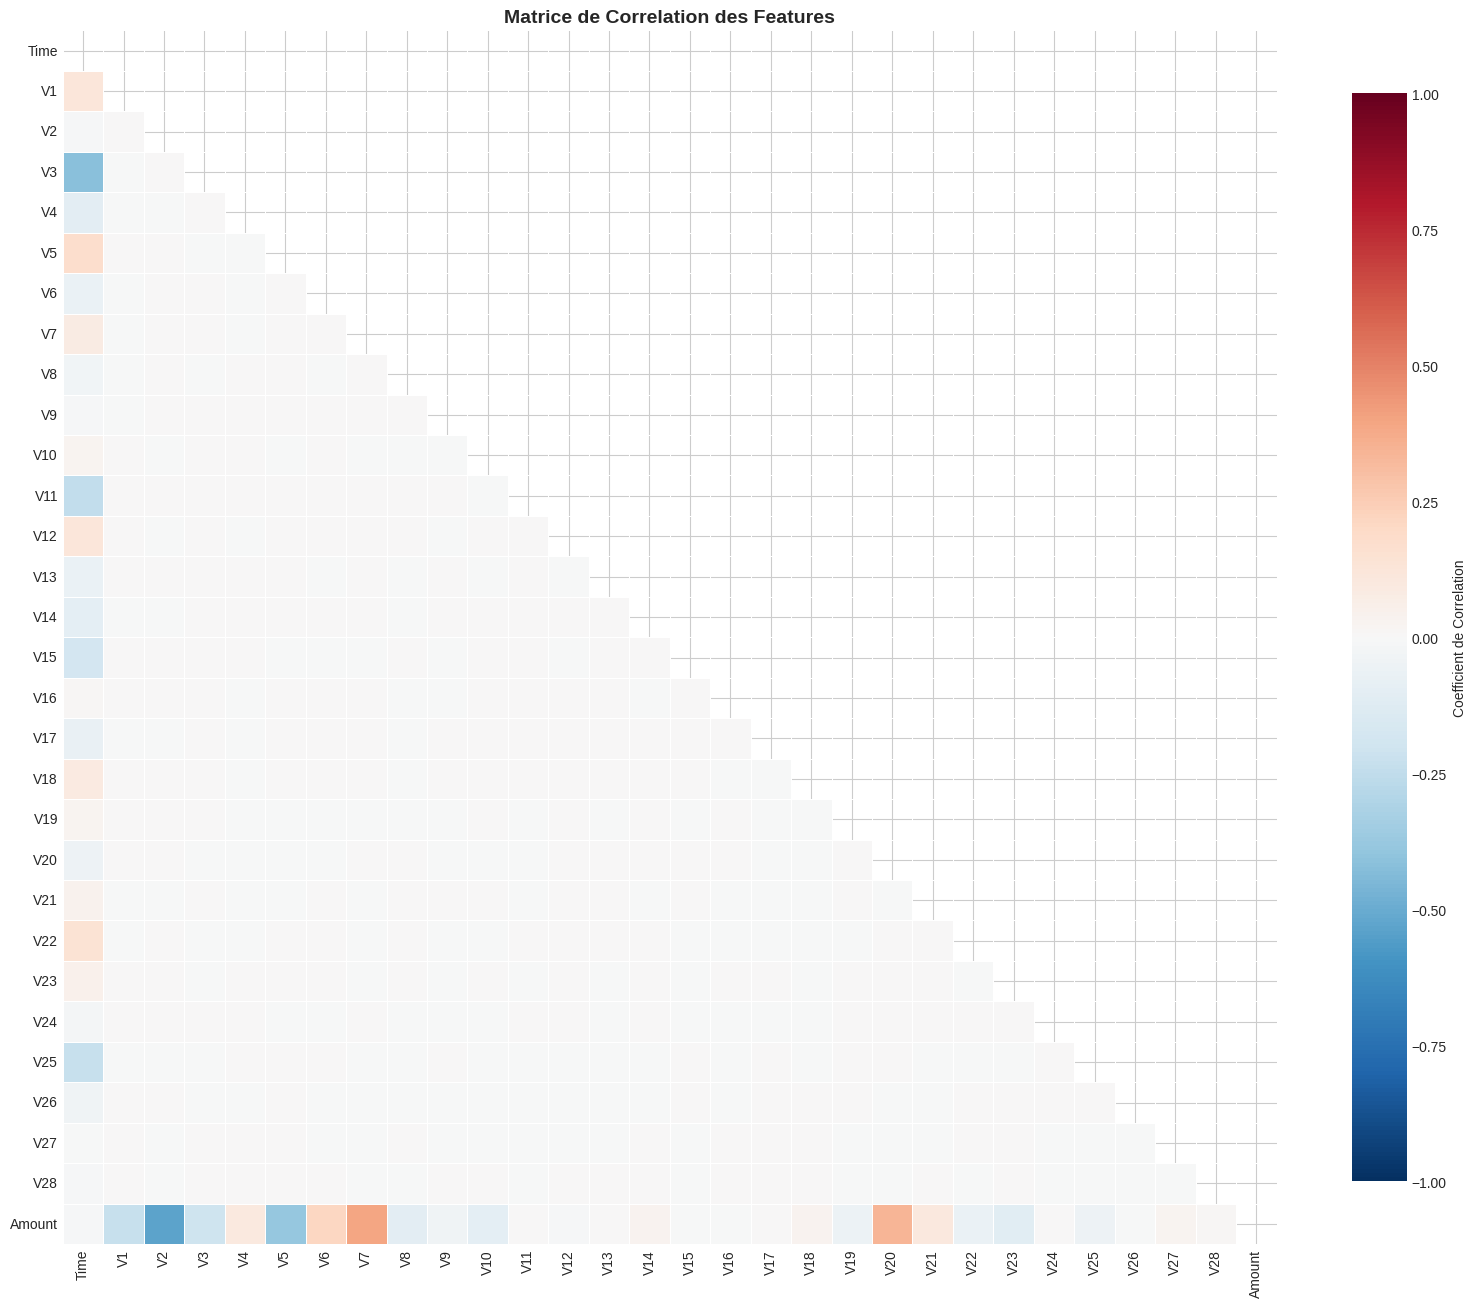


[Figure sauvegardee: fig3_correlation_matrix.png]


In [67]:
# Matrice de correlation
print("=" * 70)
print("ANALYSE DE LA COLINEARITE - MATRICE DE CORRELATION")
print("=" * 70)

# Calculer la matrice de correlation (sans la variable cible)
correlation_matrix = df.drop('Class', axis=1).corr()

# Heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5,
            vmin=-1, vmax=1,
            cbar_kws={'label': 'Coefficient de Correlation', 'shrink': 0.8})
plt.title('Matrice de Correlation des Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[Figure sauvegardee: fig3_correlation_matrix.png]")

In [68]:
# Identifier les correlations fortes (|r| > 0.5)
print("\nRecherche des correlations fortes (|r| > 0.5):")
print("-" * 50)

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            high_corr_pairs.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': round(corr_val, 4)
            })

if len(high_corr_pairs) > 0:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(high_corr_df.to_string(index=False))
else:
    print("Aucune correlation forte detectee (|r| > 0.5)")
    print("\n>>> Les features PCA (V1-V28) sont orthogonales par construction.")
    print("    C'est un avantage: pas de probleme de colinearite!")


Recherche des correlations fortes (|r| > 0.5):
--------------------------------------------------
Feature 1 Feature 2  Correlation
       V2    Amount      -0.5314


In [69]:
# VIF (Variance Inflation Factor)
print("\n" + "=" * 70)
print("ANALYSE DE LA COLINEARITE - VIF (Variance Inflation Factor)")
print("=" * 70)

print("\nInterpretation du VIF:")
print("  - VIF = 1     : Pas de correlation")
print("  - VIF < 5     : Faible correlation (acceptable)")
print("  - VIF >= 5    : Correlation moderee (a surveiller)")
print("  - VIF >= 10   : Haute correlation (problematique)")

# Features PCA pour le calcul du VIF
pca_features = [f'V{i}' for i in range(1, 29)]
X_vif = df[pca_features]

# Calculer le VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\nVIF pour les features PCA (V1-V28):")
print(vif_data.to_string(index=False))


ANALYSE DE LA COLINEARITE - VIF (Variance Inflation Factor)

Interpretation du VIF:
  - VIF = 1     : Pas de correlation
  - VIF < 5     : Faible correlation (acceptable)
  - VIF >= 5    : Correlation moderee (a surveiller)
  - VIF >= 10   : Haute correlation (problematique)

VIF pour les features PCA (V1-V28):
Feature  VIF
     V7  1.0
    V19  1.0
    V14  1.0
    V13  1.0
    V20  1.0
    V25  1.0
    V28  1.0
    V12  1.0
    V11  1.0
     V1  1.0
     V5  1.0
     V4  1.0
    V27  1.0
    V24  1.0
    V21  1.0
    V15  1.0
    V18  1.0
     V8  1.0
     V2  1.0
     V3  1.0
    V17  1.0
    V22  1.0
     V6  1.0
    V16  1.0
    V23  1.0
    V26  1.0
     V9  1.0
    V10  1.0


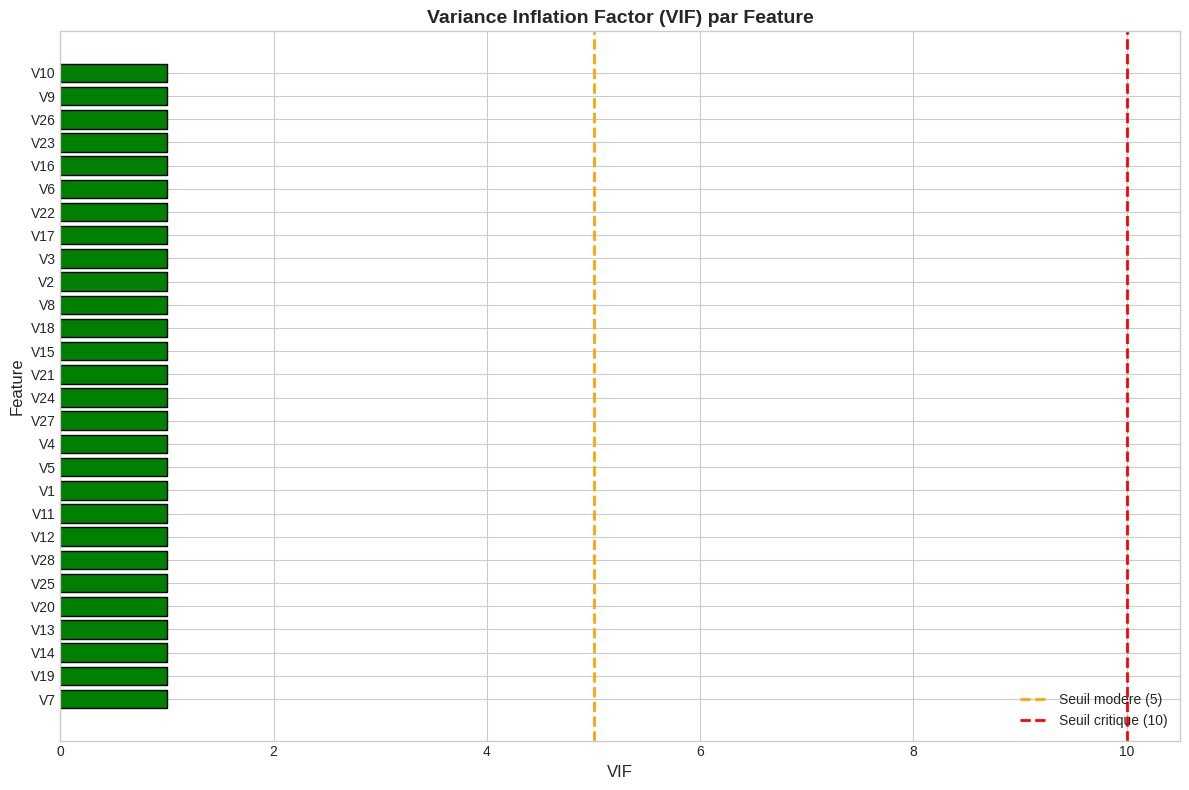


VIF maximum: 1.00
>>> CONCLUSION: Aucun probleme de colinearite detecte (tous VIF < 5)


In [70]:
# Visualisation du VIF
plt.figure(figsize=(12, 8))
colors_vif = ['red' if v >= 10 else 'orange' if v >= 5 else 'green' for v in vif_data['VIF']]
bars = plt.barh(vif_data['Feature'], vif_data['VIF'], color=colors_vif, edgecolor='black')
plt.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='Seuil modere (5)')
plt.axvline(x=10, color='red', linestyle='--', linewidth=2, label='Seuil critique (10)')
plt.xlabel('VIF', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Variance Inflation Factor (VIF) par Feature', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig4_vif_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Conclusion
max_vif = vif_data['VIF'].max()
print(f"\nVIF maximum: {max_vif:.2f}")
if max_vif < 5:
    print(">>> CONCLUSION: Aucun probleme de colinearite detecte (tous VIF < 5)")
elif max_vif < 10:
    print(">>> CONCLUSION: Colinearite moderee detectee (certains VIF entre 5 et 10)")
else:
    print(">>> CONCLUSION: Colinearite elevee detectee (certains VIF >= 10)")


CORRELATION DES FEATURES AVEC LA VARIABLE CIBLE (Class)


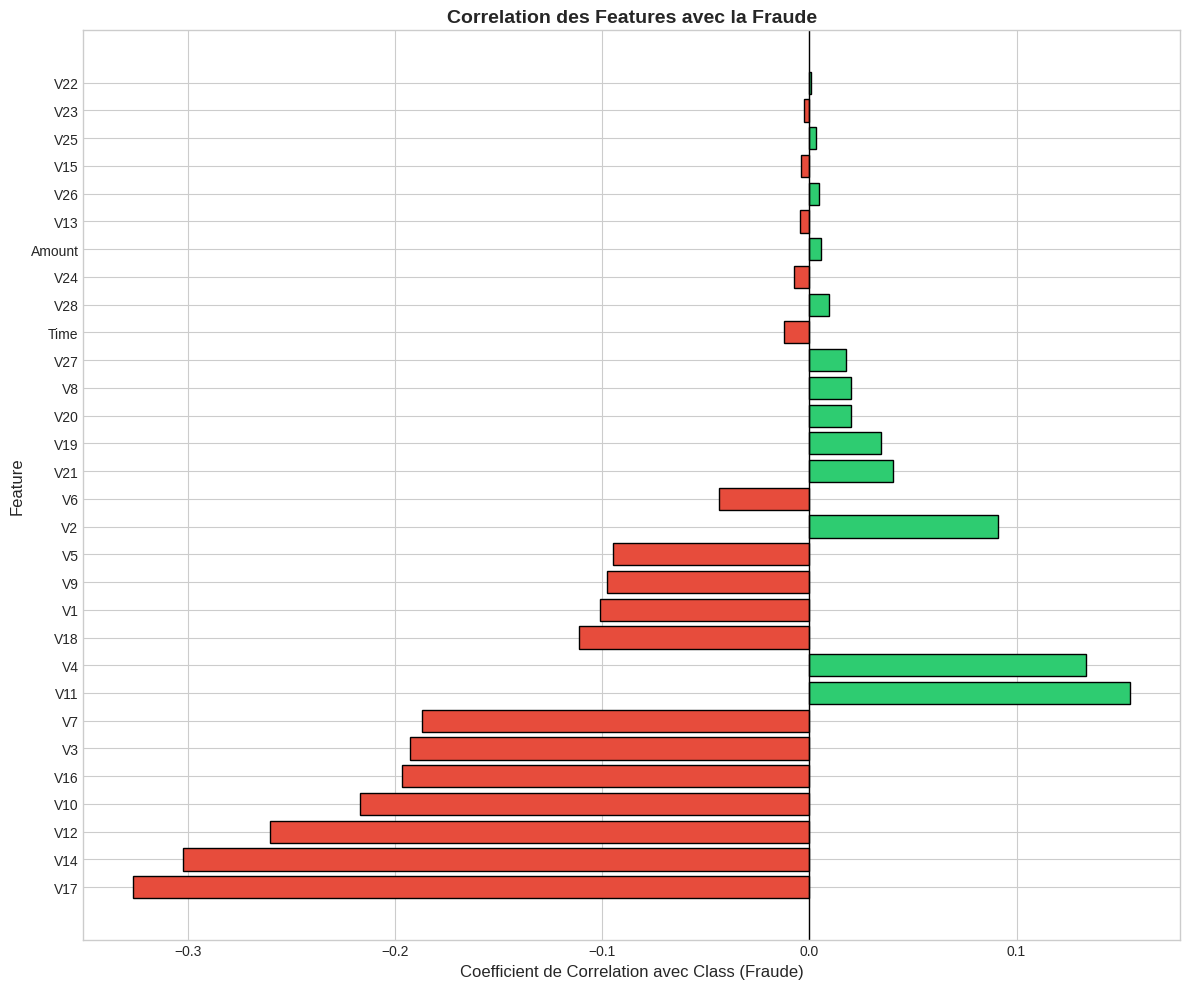


Top 10 features les plus correlees avec la fraude:
     Correlation
V17      -0.3265
V14      -0.3025
V12      -0.2606
V10      -0.2169
V16      -0.1965
V3       -0.1930
V7       -0.1873
V11       0.1549
V4        0.1334
V18      -0.1115


In [71]:
# Correlation avec la variable cible
print("\n" + "=" * 70)
print("CORRELATION DES FEATURES AVEC LA VARIABLE CIBLE (Class)")
print("=" * 70)

target_correlation = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)

plt.figure(figsize=(12, 10))
colors_target = ['#e74c3c' if c < 0 else '#2ecc71' for c in target_correlation.values]
plt.barh(target_correlation.index, target_correlation.values, color=colors_target, edgecolor='black')
plt.xlabel('Coefficient de Correlation avec Class (Fraude)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Correlation des Features avec la Fraude', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.tight_layout()
plt.savefig('fig5_target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features les plus correlees avec la fraude:")
print(target_correlation.head(10).to_frame('Correlation').round(4))

## 1.5 Preparation des Donnees

In [72]:
# Preparation des features
print("=" * 70)
print("PREPARATION DES DONNEES")
print("=" * 70)

# Feature Engineering
df_processed = df.copy()

# Transformer Time en heure de la journee (cyclique sur 24h)
df_processed['Hour'] = (df_processed['Time'] % (24 * 3600)) / 3600

# Normaliser Time
df_processed['Time_normalized'] = df_processed['Time'] / df_processed['Time'].max()

# Log-transform Amount (pour reduire l'asymetrie)
df_processed['Amount_log'] = np.log1p(df_processed['Amount'])

# Definir les features
feature_cols = pca_features + ['Amount_log', 'Hour', 'Time_normalized']
X = df_processed[feature_cols]
y = df_processed['Class']

print(f"\nFeatures selectionnees: {len(feature_cols)}")
print(f"  - PCA features: V1 a V28 (28 features)")
print(f"  - Amount_log: log(Amount + 1)")
print(f"  - Hour: heure de la journee [0-24]")
print(f"  - Time_normalized: temps normalise [0-1]")

PREPARATION DES DONNEES

Features selectionnees: 31
  - PCA features: V1 a V28 (28 features)
  - Amount_log: log(Amount + 1)
  - Hour: heure de la journee [0-24]
  - Time_normalized: temps normalise [0-1]


In [73]:
# Split Train/Test stratifie
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nSplit des donnees (80% train, 20% test):")
print(f"  - Train: {len(X_train):,} samples")
print(f"    - Non-Fraudes: {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.3f}%)")
print(f"    - Fraudes: {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.3f}%)")
print(f"  - Test: {len(X_test):,} samples")
print(f"    - Non-Fraudes: {(y_test == 0).sum():,} ({(y_test == 0).mean()*100:.3f}%)")
print(f"    - Fraudes: {(y_test == 1).sum():,} ({(y_test == 1).mean()*100:.3f}%)")


Split des donnees (80% train, 20% test):
  - Train: 227,845 samples
    - Non-Fraudes: 227,451 (99.827%)
    - Fraudes: 394 (0.173%)
  - Test: 56,962 samples
    - Non-Fraudes: 56,864 (99.828%)
    - Fraudes: 98 (0.172%)


In [74]:
# Standardisation avec RobustScaler (robuste aux outliers)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nStandardisation: RobustScaler")
print("  - Utilise la mediane et l'IQR au lieu de la moyenne et l'ecart-type")
print("  - Plus robuste aux valeurs extremes (outliers)")


Standardisation: RobustScaler
  - Utilise la mediane et l'IQR au lieu de la moyenne et l'ecart-type
  - Plus robuste aux valeurs extremes (outliers)


## 1.6 Traitement du Desequilibre - Comparaison des Approches

Nous comparons deux types d'approches:
1. **Niveau algorithmique**: `class_weight='balanced'`
2. **Niveau donnees**: SMOTE, ADASYN, NearMiss

In [75]:
# Techniques de reechantillonnage
print("=" * 70)
print("TRAITEMENT DU DESEQUILIBRE - COMPARAISON DES TECHNIQUES")
print("=" * 70)

print("\n" + "-" * 70)
print("1. SMOTE (Synthetic Minority Over-sampling Technique)")
print("-" * 70)
print("   Principe: Cree des exemples synthetiques de la classe minoritaire")
print("   en interpolant entre des exemples existants et leurs voisins.")

smote = SMOTE(random_state=42, sampling_strategy=0.5)  # 50% de la classe majoritaire
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"\n   Avant SMOTE: {len(y_train):,} samples (Fraudes: {y_train.sum():,})")
print(f"   Apres SMOTE: {len(y_train_smote):,} samples (Fraudes: {y_train_smote.sum():,})")

TRAITEMENT DU DESEQUILIBRE - COMPARAISON DES TECHNIQUES

----------------------------------------------------------------------
1. SMOTE (Synthetic Minority Over-sampling Technique)
----------------------------------------------------------------------
   Principe: Cree des exemples synthetiques de la classe minoritaire
   en interpolant entre des exemples existants et leurs voisins.

   Avant SMOTE: 227,845 samples (Fraudes: 394)
   Apres SMOTE: 341,176 samples (Fraudes: 113,725)


In [76]:
print("\n" + "-" * 70)
print("2. ADASYN (Adaptive Synthetic Sampling)")
print("-" * 70)
print("   Principe: Similaire a SMOTE, mais genere plus d'exemples dans")
print("   les regions ou la classe minoritaire est difficile a apprendre.")

adasyn = ADASYN(random_state=42, sampling_strategy=0.5)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
print(f"\n   Avant ADASYN: {len(y_train):,} samples (Fraudes: {y_train.sum():,})")
print(f"   Apres ADASYN: {len(y_train_adasyn):,} samples (Fraudes: {y_train_adasyn.sum():,})")


----------------------------------------------------------------------
2. ADASYN (Adaptive Synthetic Sampling)
----------------------------------------------------------------------
   Principe: Similaire a SMOTE, mais genere plus d'exemples dans
   les regions ou la classe minoritaire est difficile a apprendre.

   Avant ADASYN: 227,845 samples (Fraudes: 394)
   Apres ADASYN: 341,176 samples (Fraudes: 113,725)


In [77]:
print("\n" + "-" * 70)
print("3. NearMiss (Under-sampling)")
print("-" * 70)
print("   Principe: Reduit la classe majoritaire en selectionnant les")
print("   exemples les plus proches de la classe minoritaire.")

nearmiss = NearMiss(version=1)
X_train_nm, y_train_nm = nearmiss.fit_resample(X_train_scaled, y_train)
print(f"\n   Avant NearMiss: {len(y_train):,} samples (Fraudes: {y_train.sum():,})")
print(f"   Apres NearMiss: {len(y_train_nm):,} samples (Fraudes: {y_train_nm.sum():,})")


----------------------------------------------------------------------
3. NearMiss (Under-sampling)
----------------------------------------------------------------------
   Principe: Reduit la classe majoritaire en selectionnant les
   exemples les plus proches de la classe minoritaire.

   Avant NearMiss: 227,845 samples (Fraudes: 394)
   Apres NearMiss: 788 samples (Fraudes: 394)


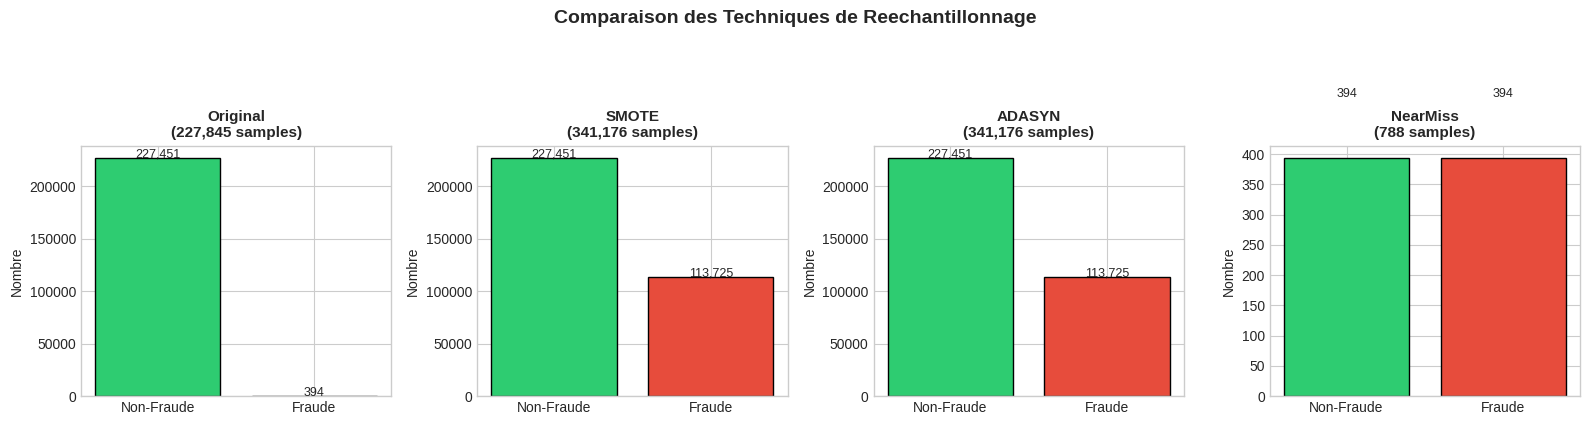

In [78]:
# Visualisation comparative
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

datasets = [
    ('Original', y_train),
    ('SMOTE', y_train_smote),
    ('ADASYN', y_train_adasyn),
    ('NearMiss', y_train_nm)
]

for ax, (name, y_data) in zip(axes, datasets):
    counts = pd.Series(y_data).value_counts().sort_index()
    bars = ax.bar(['Non-Fraude', 'Fraude'], counts.values, 
                  color=['#2ecc71', '#e74c3c'], edgecolor='black')
    ax.set_title(f'{name}\n({len(y_data):,} samples)', fontweight='bold', fontsize=11)
    ax.set_ylabel('Nombre')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
                f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Comparaison des Techniques de Reechantillonnage', 
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('fig6_resampling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
<a id='step2'></a>
# ETAPE 2: Developpement des Modeles

Nous allons construire et comparer 3 modeles:
1. **Baseline**: Regression Logistique avec Elastic Net
2. **Random Forest** avec Analyse de Proximite
3. **XGBoost** avec Cost-Sensitive Learning et Optimisation Bayesienne

## 2.1 Modele 1: Regression Logistique avec Elastic Net (Baseline)

In [79]:
print("=" * 70)
print("MODELE 1: REGRESSION LOGISTIQUE AVEC ELASTIC NET (BASELINE)")
print("=" * 70)

print("\nJustification des hyperparametres:")
print("-" * 50)
print("""
  penalty='elasticnet':
    - Combine L1 (Lasso) et L2 (Ridge)
    - L1: encourage la sparsité (certains coefficients = 0)
    - L2: regularise pour eviter l'overfitting
    
  l1_ratio=0.5:
    - Equilibre entre L1 et L2
    - 0 = Ridge pure, 1 = Lasso pure
    
  C=1.0:
    - Inverse de la force de regularisation
    - Valeur par defaut, equilibre biais-variance
    
  class_weight='balanced':
    - Pondere les classes inversement a leur frequence
    - Poids_fraude = n_total / (2 * n_fraude) ≈ 289
    
  solver='saga':
    - Seul solver compatible avec Elastic Net
    - Efficace sur grands datasets
""")

MODELE 1: REGRESSION LOGISTIQUE AVEC ELASTIC NET (BASELINE)

Justification des hyperparametres:
--------------------------------------------------

  penalty='elasticnet':
    - Combine L1 (Lasso) et L2 (Ridge)
    - L1: encourage la sparsité (certains coefficients = 0)
    - L2: regularise pour eviter l'overfitting

  l1_ratio=0.5:
    - Equilibre entre L1 et L2
    - 0 = Ridge pure, 1 = Lasso pure

  C=1.0:
    - Inverse de la force de regularisation
    - Valeur par defaut, equilibre biais-variance

  class_weight='balanced':
    - Pondere les classes inversement a leur frequence
    - Poids_fraude = n_total / (2 * n_fraude) ≈ 289

  solver='saga':
    - Seul solver compatible avec Elastic Net
    - Efficace sur grands datasets



In [80]:
# Entrainement avec class_weight='balanced'
print("\nEntrainement du modele avec class_weight='balanced'...")

lr_baseline = LogisticRegression(
    penalty='elasticnet',
    l1_ratio=0.5,
    C=1.0,
    class_weight='balanced',
    solver='saga',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_baseline.fit(X_train_scaled, y_train)
y_pred_lr = lr_baseline.predict(X_test_scaled)
y_proba_lr = lr_baseline.predict_proba(X_test_scaled)[:, 1]

print("\nResultats sur l'ensemble de test:")
print(classification_report(y_test, y_pred_lr, target_names=['Non-Fraude', 'Fraude']))


Entrainement du modele avec class_weight='balanced'...

Resultats sur l'ensemble de test:
              precision    recall  f1-score   support

  Non-Fraude       1.00      0.97      0.99     56864
      Fraude       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [81]:
# Comparaison: class_weight vs SMOTE
print("\n" + "=" * 70)
print("COMPARAISON: class_weight='balanced' vs SMOTE")
print("=" * 70)

# Modele avec SMOTE
lr_smote = LogisticRegression(
    penalty='elasticnet',
    l1_ratio=0.5,
    C=1.0,
    solver='saga',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

print("\nEntrainement avec SMOTE...")
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_lr_smote = lr_smote.predict(X_test_scaled)
y_proba_lr_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

# Tableau comparatif
comparison_lr = pd.DataFrame({
    'Metrique': ['F1-Score (Fraude)', 'Precision', 'Recall', 'MCC', 'AUPRC'],
    'class_weight': [
        round(f1_score(y_test, y_pred_lr), 4),
        round(precision_score(y_test, y_pred_lr), 4),
        round(recall_score(y_test, y_pred_lr), 4),
        round(matthews_corrcoef(y_test, y_pred_lr), 4),
        round(average_precision_score(y_test, y_proba_lr), 4)
    ],
    'SMOTE': [
        round(f1_score(y_test, y_pred_lr_smote), 4),
        round(precision_score(y_test, y_pred_lr_smote), 4),
        round(recall_score(y_test, y_pred_lr_smote), 4),
        round(matthews_corrcoef(y_test, y_pred_lr_smote), 4),
        round(average_precision_score(y_test, y_proba_lr_smote), 4)
    ]
})

print("\nComparaison des approches pour Logistic Regression:")
print(comparison_lr.to_string(index=False))

# Meilleure approche
best_f1_lr = 'class_weight' if comparison_lr['class_weight'][0] >= comparison_lr['SMOTE'][0] else 'SMOTE'
print(f"\n>>> Meilleure approche: {best_f1_lr}")


COMPARAISON: class_weight='balanced' vs SMOTE

Entrainement avec SMOTE...

Comparaison des approches pour Logistic Regression:
         Metrique  class_weight  SMOTE
F1-Score (Fraude)        0.1070 0.1980
        Precision        0.0568 0.1111
           Recall        0.9184 0.9082
              MCC        0.2249 0.3152
            AUPRC        0.7224 0.7228

>>> Meilleure approche: SMOTE



COEFFICIENTS DU MODELE ELASTIC NET


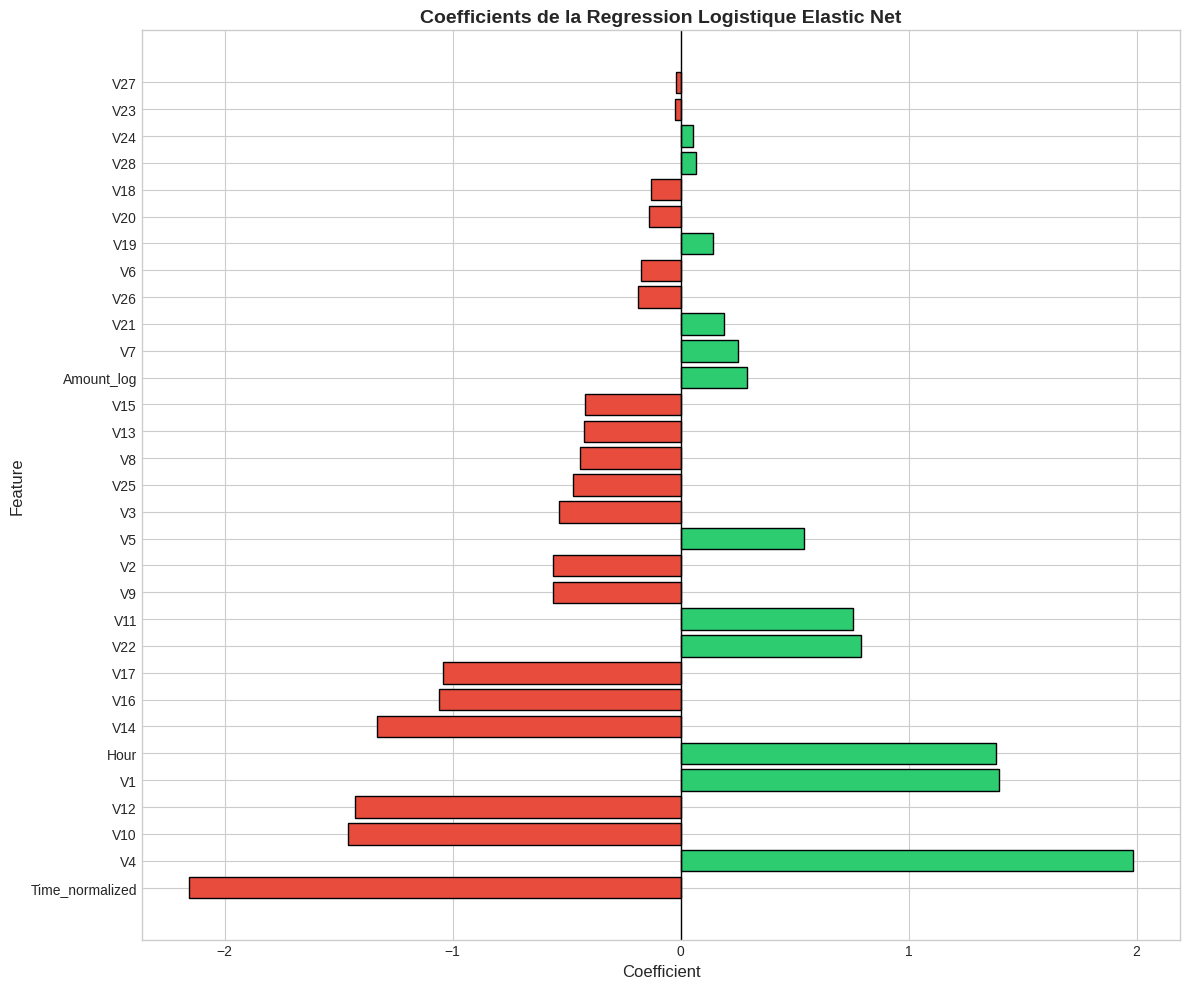


Top 10 features les plus influentes:
        Feature  Coefficient
Time_normalized    -2.156234
             V4     1.983658
            V10    -1.460339
            V12    -1.427417
             V1     1.396994
           Hour     1.384305
            V14    -1.332358
            V16    -1.060480
            V17    -1.041043
            V22     0.792050

Interpretation:
  - Coefficient positif: augmente la probabilite de fraude
  - Coefficient negatif: diminue la probabilite de fraude


In [82]:
# Coefficients du modele
print("\n" + "=" * 70)
print("COEFFICIENTS DU MODELE ELASTIC NET")
print("=" * 70)

coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_baseline.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(12, 10))
colors_coef = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient'].values]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_coef, edgecolor='black')
plt.xlabel('Coefficient', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Coefficients de la Regression Logistique Elastic Net', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.tight_layout()
plt.savefig('fig7_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features les plus influentes:")
print(coef_df.head(10).to_string(index=False))

print("\nInterpretation:")
print("  - Coefficient positif: augmente la probabilite de fraude")
print("  - Coefficient negatif: diminue la probabilite de fraude")

## 2.2 Modele 2: Random Forest avec Analyse de Proximite

In [83]:
print("=" * 70)
print("MODELE 2: RANDOM FOREST AVEC ANALYSE DE PROXIMITE")
print("=" * 70)

print("\nJustification des hyperparametres:")
print("-" * 50)
print("""
  n_estimators=200:
    - Nombre d'arbres dans la foret
    - Plus d'arbres = predictions plus stables
    - 200 est un bon compromis performance/temps
    
  max_depth=15:
    - Profondeur maximale de chaque arbre
    - Limite l'overfitting
    - 15 permet de capturer des patterns complexes
    
  min_samples_split=5:
    - Nombre minimum d'echantillons pour diviser un noeud
    - Evite les splits sur peu de donnees
    
  min_samples_leaf=2:
    - Nombre minimum d'echantillons par feuille
    - Regularisation supplementaire
    
  class_weight='balanced_subsample':
    - Recalcule les poids pour chaque bootstrap
    - Adapte a l'echantillonnage aleatoire
""")

MODELE 2: RANDOM FOREST AVEC ANALYSE DE PROXIMITE

Justification des hyperparametres:
--------------------------------------------------

  n_estimators=200:
    - Nombre d'arbres dans la foret
    - Plus d'arbres = predictions plus stables
    - 200 est un bon compromis performance/temps

  max_depth=15:
    - Profondeur maximale de chaque arbre
    - Limite l'overfitting
    - 15 permet de capturer des patterns complexes

  min_samples_split=5:
    - Nombre minimum d'echantillons pour diviser un noeud
    - Evite les splits sur peu de donnees

  min_samples_leaf=2:
    - Nombre minimum d'echantillons par feuille
    - Regularisation supplementaire

  class_weight='balanced_subsample':
    - Recalcule les poids pour chaque bootstrap
    - Adapte a l'echantillonnage aleatoire



In [84]:
# Entrainement du Random Forest
print("\nEntrainement du Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nOOB Score (Out-of-Bag): {rf_model.oob_score_:.4f}")
print("\nResultats sur l'ensemble de test:")
print(classification_report(y_test, y_pred_rf, target_names=['Non-Fraude', 'Fraude']))


Entrainement du Random Forest...

OOB Score (Out-of-Bag): 0.9995

Resultats sur l'ensemble de test:
              precision    recall  f1-score   support

  Non-Fraude       1.00      1.00      1.00     56864
      Fraude       0.90      0.82      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962




FEATURE IMPORTANCE - RANDOM FOREST


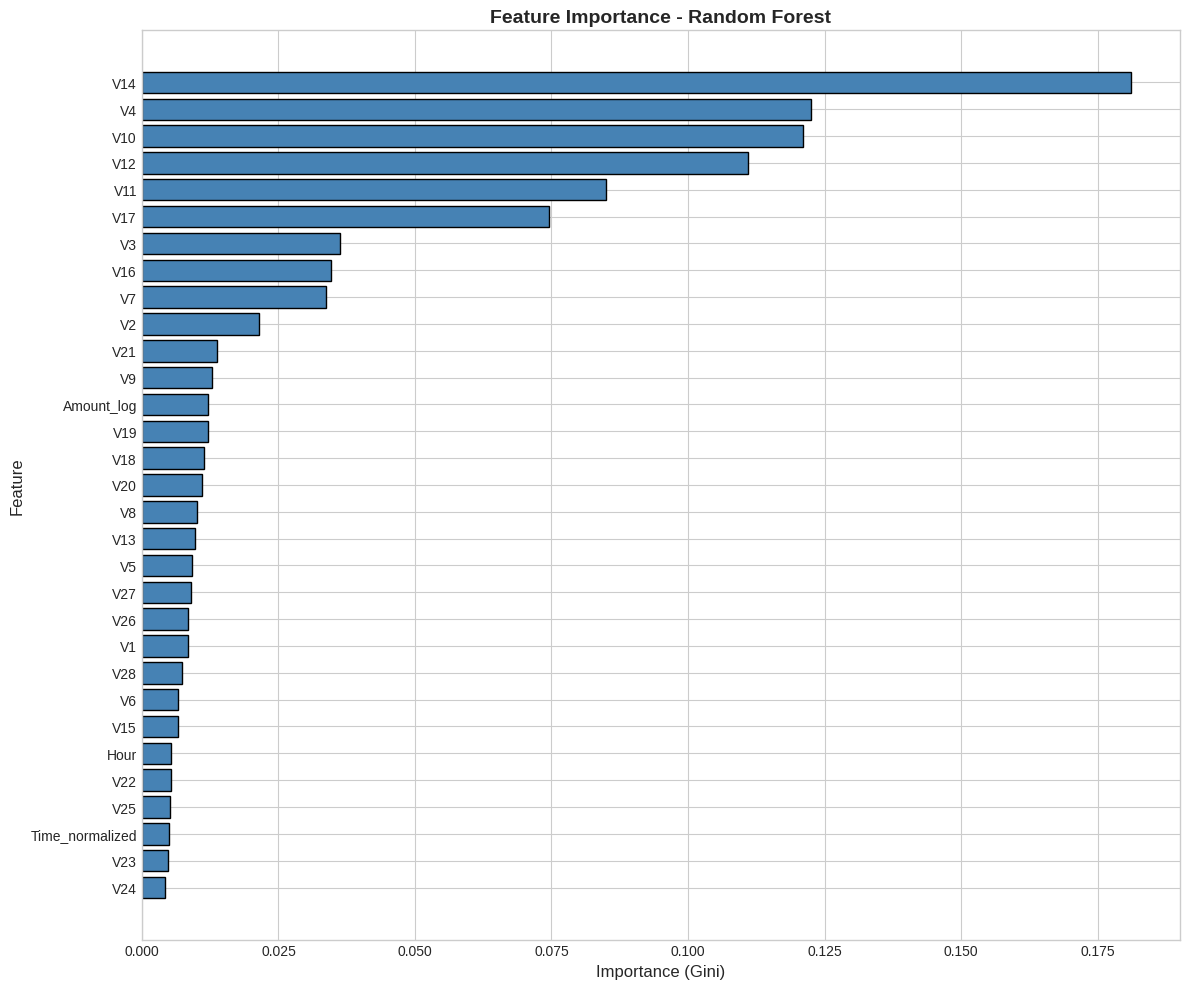


Top 10 features les plus importantes:
Feature  Importance
    V14    0.181037
     V4    0.122456
    V10    0.121118
    V12    0.110948
    V11    0.085006
    V17    0.074590
     V3    0.036187
    V16    0.034663
     V7    0.033768
     V2    0.021501


In [85]:
# Feature Importance
print("\n" + "=" * 70)
print("FEATURE IMPORTANCE - RANDOM FOREST")
print("=" * 70)

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(12, 10))
plt.barh(importance_df['Feature'], importance_df['Importance'], 
         color='steelblue', edgecolor='black')
plt.xlabel('Importance (Gini)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features les plus importantes:")
print(importance_df.sort_values('Importance', ascending=False).head(10).to_string(index=False))

In [86]:
# Analyse de Proximite
print("\n" + "=" * 70)
print("ANALYSE DE PROXIMITE - DETECTION DES OUTLIERS DE PREDICTION")
print("=" * 70)

print("""
La matrice de proximite mesure la frequence a laquelle deux observations
finissent dans la meme feuille terminale a travers tous les arbres.

Un "outlier de prediction" est une observation qui:
  - A une faible proximite moyenne avec les autres membres de sa classe
  - Est souvent mal classifiee par le modele
""")

# Sous-echantillon pour l'analyse (memoire limitee)
np.random.seed(42)
sample_size = 5000
sample_idx = np.random.choice(len(X_test_scaled), min(sample_size, len(X_test_scaled)), replace=False)
X_sample = X_test_scaled[sample_idx]
y_sample = y_test.iloc[sample_idx].values

print(f"\nCalcul de la matrice de proximite sur {len(X_sample)} echantillons...")

# Obtenir les indices des feuilles
leaf_indices = rf_model.apply(X_sample)  # Shape: (n_samples, n_trees)

# Calculer la proximite
n_samples = len(X_sample)
n_trees = rf_model.n_estimators

proximity_matrix = np.zeros((n_samples, n_samples))
for tree_idx in range(n_trees):
    leaves = leaf_indices[:, tree_idx]
    for i in range(n_samples):
        same_leaf = (leaves == leaves[i])
        proximity_matrix[i, :] += same_leaf

proximity_matrix /= n_trees
np.fill_diagonal(proximity_matrix, 1.0)

print(f"Matrice de proximite: {proximity_matrix.shape}")


ANALYSE DE PROXIMITE - DETECTION DES OUTLIERS DE PREDICTION

La matrice de proximite mesure la frequence a laquelle deux observations
finissent dans la meme feuille terminale a travers tous les arbres.

Un "outlier de prediction" est une observation qui:
  - A une faible proximite moyenne avec les autres membres de sa classe
  - Est souvent mal classifiee par le modele


Calcul de la matrice de proximite sur 5000 echantillons...
Matrice de proximite: (5000, 5000)


In [87]:
# Calculer les scores d'outlier
print("\nCalcul des scores d'outlier...")

outlier_scores = []
for i in range(n_samples):
    # Masque pour la meme classe (sans soi-meme)
    same_class_mask = (y_sample == y_sample[i])
    same_class_mask[i] = False
    
    if same_class_mask.sum() > 0:
        avg_proximity = proximity_matrix[i, same_class_mask].mean()
    else:
        avg_proximity = 0
    
    # Score d'outlier = 1 - proximite moyenne
    outlier_scores.append(1 - avg_proximity)

outlier_scores = np.array(outlier_scores)

# Predictions
y_pred_sample = rf_model.predict(X_sample)
y_proba_sample = rf_model.predict_proba(X_sample)[:, 1]
misclassified = (y_pred_sample != y_sample)

# DataFrame
outlier_df = pd.DataFrame({
    'True_Label': y_sample,
    'Predicted': y_pred_sample,
    'Proba_Fraud': y_proba_sample,
    'Outlier_Score': outlier_scores,
    'Misclassified': misclassified
})


Calcul des scores d'outlier...


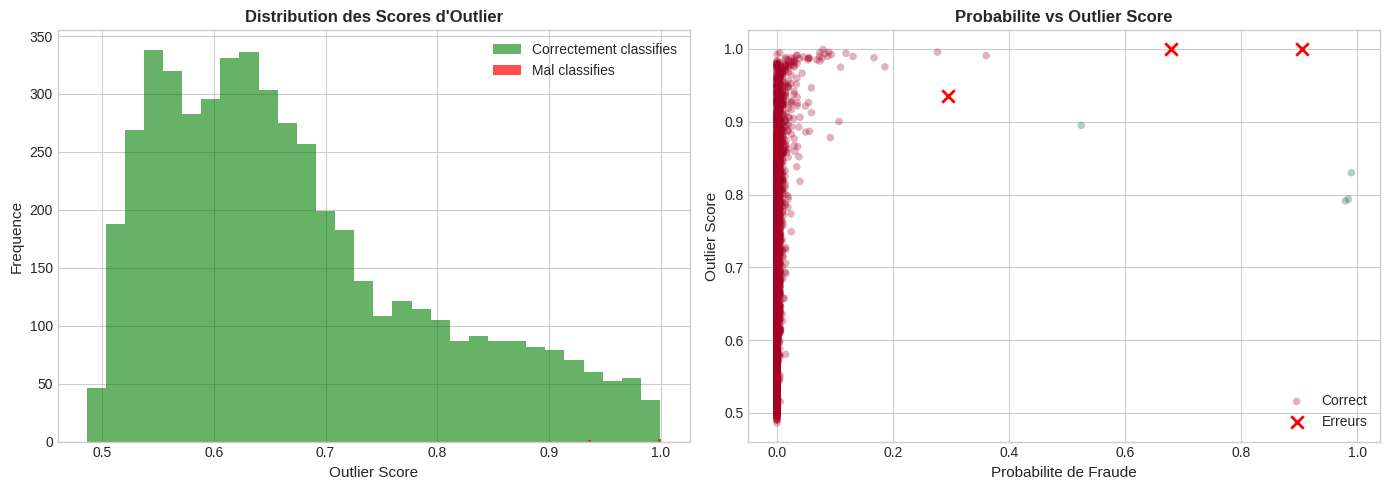

In [88]:
# Visualisation des outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des scores d'outlier
axes[0].hist(outlier_scores[~misclassified], bins=30, alpha=0.6, 
             label='Correctement classifies', color='green')
axes[0].hist(outlier_scores[misclassified], bins=30, alpha=0.7, 
             label='Mal classifies', color='red')
axes[0].set_xlabel('Outlier Score', fontsize=11)
axes[0].set_ylabel('Frequence', fontsize=11)
axes[0].set_title('Distribution des Scores d\'Outlier', fontweight='bold')
axes[0].legend()

# Scatter: Probabilite vs Outlier Score
scatter = axes[1].scatter(y_proba_sample[~misclassified], outlier_scores[~misclassified], 
                          c=y_sample[~misclassified], cmap='RdYlGn', alpha=0.3, 
                          edgecolors='none', s=30, label='Correct')
axes[1].scatter(y_proba_sample[misclassified], outlier_scores[misclassified], 
                marker='x', s=80, color='red', linewidth=2, label='Erreurs')
axes[1].set_xlabel('Probabilite de Fraude', fontsize=11)
axes[1].set_ylabel('Outlier Score', fontsize=11)
axes[1].set_title('Probabilite vs Outlier Score', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig9_proximity_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

In [89]:
# Analyse des erreurs
print("\n" + "=" * 70)
print("ANALYSE DES OUTLIERS DE PREDICTION")
print("=" * 70)

# Faux positifs et faux negatifs
false_positives = outlier_df[(outlier_df['True_Label'] == 0) & (outlier_df['Predicted'] == 1)]
false_negatives = outlier_df[(outlier_df['True_Label'] == 1) & (outlier_df['Predicted'] == 0)]

print(f"\nFaux Positifs (Non-Fraude predite comme Fraude): {len(false_positives)}")
if len(false_positives) > 0:
    print(f"  - Outlier Score moyen: {false_positives['Outlier_Score'].mean():.4f}")
    print(f"  - Probabilite moyenne: {false_positives['Proba_Fraud'].mean():.4f}")

print(f"\nFaux Negatifs (Fraude predite comme Non-Fraude): {len(false_negatives)}")
if len(false_negatives) > 0:
    print(f"  - Outlier Score moyen: {false_negatives['Outlier_Score'].mean():.4f}")
    print(f"  - Probabilite moyenne: {false_negatives['Proba_Fraud'].mean():.4f}")

print("\n" + "-" * 70)
print("INTERPRETATION DES OUTLIERS")
print("-" * 70)
print("""
Les outliers de prediction sont des observations difficiles a classifier:

1. Faux Negatifs (Fraudes manquees) - CRITIQUES:
   - Nouvelles techniques de fraude non vues pendant l'entrainement
   - Fraudes qui imitent parfaitement des transactions legitimes
   - Ces cas necessitent une attention particuliere!
   
2. Faux Positifs (Fausses alertes):
   - Transactions legitimes avec des patterns inhabituels
   - Comportements atypiques mais non frauduleux
   - Moins critiques mais impactent l'experience client
   
Un score d'outlier eleve indique que l'observation ne ressemble pas
aux autres membres de sa classe - d'ou la difficulte de classification.
""")


ANALYSE DES OUTLIERS DE PREDICTION

Faux Positifs (Non-Fraude predite comme Fraude): 2
  - Outlier Score moyen: 0.9999
  - Probabilite moyenne: 0.7920

Faux Negatifs (Fraude predite comme Non-Fraude): 1
  - Outlier Score moyen: 0.9350
  - Probabilite moyenne: 0.2946

----------------------------------------------------------------------
INTERPRETATION DES OUTLIERS
----------------------------------------------------------------------

Les outliers de prediction sont des observations difficiles a classifier:

1. Faux Negatifs (Fraudes manquees) - CRITIQUES:
   - Nouvelles techniques de fraude non vues pendant l'entrainement
   - Fraudes qui imitent parfaitement des transactions legitimes
   - Ces cas necessitent une attention particuliere!

2. Faux Positifs (Fausses alertes):
   - Transactions legitimes avec des patterns inhabituels
   - Comportements atypiques mais non frauduleux
   - Moins critiques mais impactent l'experience client

Un score d'outlier eleve indique que l'observatio

## 2.3 Modele 3: XGBoost avec Cost-Sensitive Learning et Optimisation Bayesienne

In [90]:
print("=" * 70)
print("MODELE 3: XGBOOST AVEC COST-SENSITIVE LEARNING")
print("=" * 70)

print("""
XGBoost (eXtreme Gradient Boosting) est un algorithme de boosting qui:
  - Construit des arbres sequentiellement
  - Chaque arbre corrige les erreurs du precedent
  - Optimise une fonction de perte via gradient descent

Strategies Cost-Sensitive pour gerer le desequilibre:

1. scale_pos_weight:
   - Pondere les gradients de la classe positive
   - Valeur = n_negative / n_positive
   
2. Fonction de perte personnalisee (Focal Loss):
   - Donne plus de poids aux exemples difficiles
   - Reduit l'impact des exemples faciles
""")

# Calculer scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight calcule: {scale_pos_weight:.2f}")

MODELE 3: XGBOOST AVEC COST-SENSITIVE LEARNING

XGBoost (eXtreme Gradient Boosting) est un algorithme de boosting qui:
  - Construit des arbres sequentiellement
  - Chaque arbre corrige les erreurs du precedent
  - Optimise une fonction de perte via gradient descent

Strategies Cost-Sensitive pour gerer le desequilibre:

1. scale_pos_weight:
   - Pondere les gradients de la classe positive
   - Valeur = n_negative / n_positive

2. Fonction de perte personnalisee (Focal Loss):
   - Donne plus de poids aux exemples difficiles
   - Reduit l'impact des exemples faciles


scale_pos_weight calcule: 577.29


In [91]:
# Optimisation Bayesienne avec Optuna
print("\n" + "=" * 70)
print("OPTIMISATION BAYESIENNE AVEC OPTUNA (TPE Sampler)")
print("=" * 70)

print("""
Optuna utilise le TPE (Tree-structured Parzen Estimator) pour:
  - Explorer intelligemment l'espace des hyperparametres
  - Converger plus rapidement que GridSearch
  - Exploiter les bons hyperparametres tout en explorant

Justification de l'espace de recherche:
-" * 50
  max_depth [3, 10]:
    - Controle la complexite des arbres
    - Trop profond = overfitting, trop shallow = underfitting
    
  learning_rate [0.01, 0.3] (log-scale):
    - Taux d'apprentissage pour le boosting
    - Faible = convergence lente mais precise
    
  n_estimators [100, 500]:
    - Nombre d'arbres (iterations de boosting)
    - Plus = meilleur mais risque d'overfitting
    
  min_child_weight [1, 10]:
    - Poids minimum pour creer une feuille
    - Regularisation contre l'overfitting
    
  subsample [0.6, 1.0]:
    - Fraction des donnees par arbre
    - Stochasticity pour reduire l'overfitting
    
  colsample_bytree [0.6, 1.0]:
    - Fraction des features par arbre
    - Diversite entre les arbres
    
  reg_lambda [1e-8, 10] (log-scale):
    - Regularisation L2 sur les poids
    
  reg_alpha [1e-8, 10] (log-scale):
    - Regularisation L1 sur les poids
""")


OPTIMISATION BAYESIENNE AVEC OPTUNA (TPE Sampler)

Optuna utilise le TPE (Tree-structured Parzen Estimator) pour:
  - Explorer intelligemment l'espace des hyperparametres
  - Converger plus rapidement que GridSearch
  - Exploiter les bons hyperparametres tout en explorant

Justification de l'espace de recherche:
-" * 50
  max_depth [3, 10]:
    - Controle la complexite des arbres
    - Trop profond = overfitting, trop shallow = underfitting

  learning_rate [0.01, 0.3] (log-scale):
    - Taux d'apprentissage pour le boosting
    - Faible = convergence lente mais precise

  n_estimators [100, 500]:
    - Nombre d'arbres (iterations de boosting)
    - Plus = meilleur mais risque d'overfitting

  min_child_weight [1, 10]:
    - Poids minimum pour creer une feuille
    - Regularisation contre l'overfitting

  subsample [0.6, 1.0]:
    - Fraction des donnees par arbre
    - Stochasticity pour reduire l'overfitting

  colsample_bytree [0.6, 1.0]:
    - Fraction des features par arbre
    - 

In [ ]:
# Fonction objectif pour Optuna
def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'scale_pos_weight': scale_pos_weight,
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr',
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = xgb.XGBClassifier(**params)
    
    # Cross-validation stratifiee
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train, 
                             cv=cv, scoring='f1', n_jobs=-1)
    
    return scores.mean()

# Lancer l'optimisation
print("\nLancement de l'optimisation Bayesienne (50 trials)...")
print("(Cela peut prendre quelques minutes)\n")

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nOptimisation terminee!")
print(f"Meilleur score F1 (CV): {study.best_value:.4f}")
print(f"\nMeilleurs hyperparametres:")
for key, value in study.best_params.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: {value}")


Lancement de l'optimisation Bayesienne (50 trials)...
(Cela peut prendre quelques minutes)



  0%|          | 0/50 [00:00<?, ?it/s]

[W 2026-05-29 10:09:23,223] Trial 13 failed with parameters: {'max_depth': 4, 'learning_rate': 0.20400981538892832, 'n_estimators': 321, 'min_child_weight': 8, 'subsample': 0.7019796076799771, 'colsample_bytree': 0.6011963818007375, 'reg_lambda': 0.0012004114082688447, 'reg_alpha': 0.018012468361264265} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/mapster/ABOUBAKER/SDIA_PRACTICES/SCHOOL/AI_ADVANCED/FINAL_PROJECT/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_30156/3555783296.py", line 23, in objective
    scores = cross_val_score(model, X_train_scaled, y_train,
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mapster/ABOUBAKER/SDIA_PRACTICES/SCHOOL/AI_ADVANCED/FINAL_PROJECT/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return 

KeyboardInterrupt: 

In [ ]:
# Visualisation de la convergence Optuna
print("\n" + "=" * 70)
print("ANALYSE DE LA CONVERGENCE - OPTUNA")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimization History
trials = study.trials
trial_numbers = [t.number for t in trials]
trial_values = [t.value if t.value is not None else 0 for t in trials]
best_values = [max(trial_values[:i+1]) for i in range(len(trial_values))]

axes[0].scatter(trial_numbers, trial_values, alpha=0.5, c='steelblue', s=50, label='Objective Value')
axes[0].plot(trial_numbers, best_values, 'r-', linewidth=2, label='Best Value')
axes[0].set_xlabel('Trial', fontsize=11)
axes[0].set_ylabel('F1 Score (CV)', fontsize=11)
axes[0].set_title('Historique d\'Optimisation', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Parameter Importance
try:
    importance = optuna.importance.get_param_importances(study)
    params_names = list(importance.keys())
    importances = list(importance.values())
    
    axes[1].barh(params_names, importances, color='steelblue', edgecolor='black')
    axes[1].set_xlabel('Importance', fontsize=11)
    axes[1].set_title('Importance des Hyperparametres', fontweight='bold')
except Exception as e:
    axes[1].text(0.5, 0.5, f'Calcul d\'importance non disponible', 
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('fig10_optuna_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAnalyse de la convergence:")
print(f"  - Score initial: {trial_values[0]:.4f}")
print(f"  - Meilleur score: {max(trial_values):.4f}")
print(f"  - Amelioration: +{(max(trial_values) - trial_values[0])*100:.2f}%")

In [ ]:
# Entrainer le modele final avec les meilleurs parametres
print("\n" + "=" * 70)
print("MODELE XGBOOST FINAL (avec scale_pos_weight)")
print("=" * 70)

best_params = study.best_params.copy()
best_params.update({
    'scale_pos_weight': scale_pos_weight,
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'random_state': 42,
    'n_jobs': -1
})

xgb_model = xgb.XGBClassifier(**best_params)
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("\nResultats sur l'ensemble de test:")
print(classification_report(y_test, y_pred_xgb, target_names=['Non-Fraude', 'Fraude']))

In [ ]:
# Comparaison: scale_pos_weight vs Focal Loss
print("\n" + "=" * 70)
print("COMPARAISON: scale_pos_weight vs FOCAL LOSS")
print("=" * 70)

print("""
Focal Loss: Fonction de perte qui donne plus de poids aux exemples
difficiles a classifier. Parametre gamma controle le focus.

FL(p) = -alpha * (1-p)^gamma * log(p)  pour la classe positive
""")

# Focal Loss personnalisee
def focal_loss_objective(y_true, y_pred):
    gamma = 2.0
    alpha = 0.75
    
    y_pred = 1 / (1 + np.exp(-y_pred))
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
    
    pt = np.where(y_true == 1, y_pred, 1 - y_pred)
    alpha_t = np.where(y_true == 1, alpha, 1 - alpha)
    
    grad = alpha_t * (gamma * (1 - pt) ** (gamma - 1) * pt * np.log(pt + 1e-7) - 
                      (1 - pt) ** gamma) * (y_true - y_pred)
    hess = alpha_t * (1 - pt) ** gamma * (1 - y_pred) * y_pred + 1e-7
    
    return -grad, hess

# Entrainer avec Focal Loss
focal_params = study.best_params.copy()
focal_params.update({
    'objective': focal_loss_objective,
    'random_state': 42,
    'n_jobs': -1
})

print("\nEntrainement avec Focal Loss...")
xgb_focal = xgb.XGBClassifier(**focal_params)
xgb_focal.fit(X_train_scaled, y_train)

y_pred_focal = xgb_focal.predict(X_test_scaled)
y_proba_focal = xgb_focal.predict_proba(X_test_scaled)[:, 1]

# Comparaison
comparison_xgb = pd.DataFrame({
    'Metrique': ['F1-Score', 'Precision', 'Recall', 'MCC', 'AUPRC'],
    'scale_pos_weight': [
        round(f1_score(y_test, y_pred_xgb), 4),
        round(precision_score(y_test, y_pred_xgb), 4),
        round(recall_score(y_test, y_pred_xgb), 4),
        round(matthews_corrcoef(y_test, y_pred_xgb), 4),
        round(average_precision_score(y_test, y_proba_xgb), 4)
    ],
    'Focal Loss': [
        round(f1_score(y_test, y_pred_focal), 4),
        round(precision_score(y_test, y_pred_focal), 4),
        round(recall_score(y_test, y_pred_focal), 4),
        round(matthews_corrcoef(y_test, y_pred_focal), 4),
        round(average_precision_score(y_test, y_proba_focal), 4)
    ]
})

print("\nComparaison des strategies Cost-Sensitive:")
print(comparison_xgb.to_string(index=False))

best_strategy = 'scale_pos_weight' if comparison_xgb['scale_pos_weight'][0] >= comparison_xgb['Focal Loss'][0] else 'Focal Loss'
print(f"\n>>> Meilleure strategie: {best_strategy}")

---
<a id='step3'></a>
# ETAPE 3: Evaluation et Calibration

## 3.1 Metriques Avancees

In [ ]:
print("=" * 70)
print("EVALUATION DES MODELES - METRIQUES AVANCEES")
print("=" * 70)

print("""
POURQUOI NE PAS UTILISER L'ACCURACY?
-" * 50
Avec 99.83% de non-fraudes, un modele qui predit TOUJOURS "Non-Fraude"
atteindrait 99.83% d'accuracy... mais detecterait 0 fraude!

METRIQUES APPROPRIEES:

1. F1-Score (classe Fraude):
   - Moyenne harmonique de Precision et Recall
   - F1 = 2 * (Precision * Recall) / (Precision + Recall)
   - Equilibre entre faux positifs et faux negatifs

2. F1-Macro:
   - Moyenne des F1 de chaque classe (non-ponderee)
   - Donne un poids egal a chaque classe

3. AUPRC (Area Under Precision-Recall Curve):
   - Surface sous la courbe Precision-Recall
   - Plus informative que AUC-ROC pour donnees desequilibrees
   - Baseline = proportion de la classe positive (0.17%)

4. MCC (Matthews Correlation Coefficient):
   - Coefficient de correlation entre predictions et realite
   - Plage: [-1, 1], ou 1 = prediction parfaite
   - Considere les 4 cases de la matrice de confusion
   - Robuste au desequilibre des classes
""")

In [ ]:
# Tableau comparatif des 3 modeles
models = {
    'Logistic Regression': (y_pred_lr, y_proba_lr),
    'Random Forest': (y_pred_rf, y_proba_rf),
    'XGBoost': (y_pred_xgb, y_proba_xgb)
}

results = []
for name, (y_pred, y_proba) in models.items():
    results.append({
        'Modele': name,
        'F1-Score (Fraude)': round(f1_score(y_test, y_pred), 4),
        'F1-Macro': round(f1_score(y_test, y_pred, average='macro'), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'MCC': round(matthews_corrcoef(y_test, y_pred), 4),
        'AUPRC': round(average_precision_score(y_test, y_proba), 4),
        'AUC-ROC': round(roc_auc_score(y_test, y_proba), 4)
    })

results_df = pd.DataFrame(results)
print("\nCOMPARAISON DES MODELES:")
print("=" * 90)
print(results_df.to_string(index=False))

# Meilleur modele
best_idx = results_df['F1-Score (Fraude)'].idxmax()
best_model = results_df.loc[best_idx, 'Modele']
print(f"\n>>> MEILLEUR MODELE (base sur F1-Score): {best_model}")

In [ ]:
# Matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (y_pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Fraude', 'Fraude'],
                yticklabels=['Non-Fraude', 'Fraude'],
                annot_kws={'size': 12})
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_xlabel('Prediction', fontsize=10)
    ax.set_ylabel('Realite', fontsize=10)

plt.suptitle('Matrices de Confusion', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('fig11_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Courbes PR et ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_models = ['#3498db', '#2ecc71', '#e74c3c']

# Precision-Recall Curves
for (name, (_, y_proba)), color in zip(models.items(), colors_models):
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[0].plot(recall, precision, label=f'{name} (AP={ap:.3f})', linewidth=2, color=color)

# Baseline (proportion de fraudes)
baseline = y_test.mean()
axes[0].axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.4f})')
axes[0].set_xlabel('Recall', fontsize=11)
axes[0].set_ylabel('Precision', fontsize=11)
axes[0].set_title('Courbes Precision-Recall', fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# ROC Curves
for (name, (_, y_proba)), color in zip(models.items(), colors_models):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2, color=color)

axes[1].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('Courbes ROC', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig12_pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.2 Calibration des Probabilites

In [ ]:
print("=" * 70)
print("CALIBRATION DES PROBABILITES")
print("=" * 70)

print("""
POURQUOI LA CALIBRATION EST IMPORTANTE?

Un modele bien calibre produit des probabilites qui refletent
la vraie probabilite d'appartenance a une classe.

Exemple:
  Si le modele predit P(Fraude) = 0.8 pour 100 transactions,
  alors environ 80 d'entre elles devraient etre des fraudes.

C'est crucial pour:
  - Prise de decision basee sur des seuils de risque
  - Estimation des couts attendus
  - Communication avec les parties prenantes

DIAGRAMME DE FIABILITE (Reliability Diagram):
  - Axe X: Probabilite predite (moyenne par bin)
  - Axe Y: Fraction reelle de positifs
  - Diagonale = calibration parfaite
  - Au-dessus: sous-confiance
  - En-dessous: sur-confiance
""")

In [ ]:
# Diagrammes de Fiabilite
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (_, y_proba)) in zip(axes, models.items()):
    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='uniform')
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Parfaitement calibre')
    ax.plot(prob_pred, prob_true, 'o-', color='steelblue', linewidth=2, 
            markersize=8, label='Modele')
    ax.fill_between(prob_pred, prob_true, prob_pred, alpha=0.2, color='steelblue')
    ax.set_xlabel('Probabilite predite moyenne', fontsize=10)
    ax.set_ylabel('Fraction de positifs', fontsize=10)
    ax.set_title(name, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('Diagrammes de Fiabilite (Reliability Diagrams)', 
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('fig13_reliability_diagrams.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Calibration du meilleur modele (XGBoost)
print("\n" + "=" * 70)
print("APPLICATION DE LA CALIBRATION SUR XGBOOST")
print("=" * 70)

print("""
Techniques de calibration:

1. Platt Scaling (Sigmoid):
   - Ajuste une regression logistique sur les scores
   - P_calibree = sigmoid(a * score + b)
   - Fonctionne bien si la miscalibration est monotone

2. Isotonic Regression:
   - Ajuste une fonction monotone par morceaux
   - Plus flexible que Platt Scaling
   - Risque d'overfitting sur petits datasets
""")

# Platt Scaling
print("\nApplication de Platt Scaling...")
xgb_platt = CalibratedClassifierCV(xgb_model, method='sigmoid', cv=5)
xgb_platt.fit(X_train_scaled, y_train)
y_proba_platt = xgb_platt.predict_proba(X_test_scaled)[:, 1]

# Isotonic Regression
print("Application de Isotonic Regression...")
xgb_isotonic = CalibratedClassifierCV(xgb_model, method='isotonic', cv=5)
xgb_isotonic.fit(X_train_scaled, y_train)
y_proba_isotonic = xgb_isotonic.predict_proba(X_test_scaled)[:, 1]

print("Calibration terminee!")

In [ ]:
# Comparaison de la calibration
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

calibrations = [
    ('XGBoost (Non calibre)', y_proba_xgb),
    ('XGBoost + Platt Scaling', y_proba_platt),
    ('XGBoost + Isotonic', y_proba_isotonic)
]

for ax, (name, y_proba) in zip(axes, calibrations):
    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='uniform')
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Parfait')
    ax.plot(prob_pred, prob_true, 'o-', color='steelblue', linewidth=2, markersize=8)
    ax.fill_between(prob_pred, prob_true, prob_pred, alpha=0.2, color='steelblue')
    ax.set_xlabel('Probabilite predite', fontsize=10)
    ax.set_ylabel('Fraction de positifs', fontsize=10)
    ax.set_title(name, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('Comparaison des Methodes de Calibration', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('fig14_calibration_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Brier Score
print("\n" + "=" * 70)
print("BRIER SCORE (Mesure de Calibration)")
print("=" * 70)

print("""
Brier Score = moyenne des (probabilite - realite)^2
  - Plage: [0, 1]
  - 0 = calibration parfaite
  - Plus bas = mieux calibre
""")

brier_scores = {
    'XGBoost (Non calibre)': brier_score_loss(y_test, y_proba_xgb),
    'XGBoost + Platt Scaling': brier_score_loss(y_test, y_proba_platt),
    'XGBoost + Isotonic': brier_score_loss(y_test, y_proba_isotonic)
}

brier_df = pd.DataFrame({
    'Methode': list(brier_scores.keys()),
    'Brier Score': [round(v, 6) for v in brier_scores.values()]
})

print(brier_df.to_string(index=False))

best_calibration = min(brier_scores, key=brier_scores.get)
print(f"\n>>> Meilleure calibration: {best_calibration}")

---
<a id='step4'></a>
# ETAPE 4: Interpretabilite (SHAP)

In [ ]:
print("=" * 70)
print("INTERPRETABILITE AVEC SHAP")
print("=" * 70)

print("""
SHAP (SHapley Additive exPlanations)

Base sur les valeurs de Shapley de la theorie des jeux:
  - Chaque feature recoit une "part" de la prediction
  - La somme des parts = prediction - baseline
  - Mathematiquement optimal et consistant

Types d'analyses:
  1. Global: Quelles features sont importantes en general?
  2. Local: Pourquoi CETTE transaction est classee fraude?
""")

In [ ]:
# Calculer les valeurs SHAP
print("\nCalcul des valeurs SHAP pour XGBoost...")

# Sous-echantillon pour accelerer
np.random.seed(42)
shap_sample_size = 1000
shap_idx = np.random.choice(len(X_test_scaled), min(shap_sample_size, len(X_test_scaled)), replace=False)
X_shap = X_test_scaled[shap_idx]
y_shap = y_test.iloc[shap_idx]

# Creer l'explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

print(f"Valeurs SHAP calculees pour {len(X_shap)} echantillons.")

In [ ]:
# Summary Plot - Importance globale
print("\n" + "=" * 70)
print("IMPORTANCE GLOBALE DES FEATURES (SHAP Summary Plot)")
print("=" * 70)

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, show=False, max_display=31)
plt.title('SHAP Summary Plot - Impact des Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig15_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Interpretation du Summary Plot:
  - Chaque point = une observation
  - Position horizontale = impact SHAP (contribution a la prediction)
  - Couleur = valeur de la feature (rouge = elevee, bleu = basse)
  - Features ordonnees par importance moyenne
""")

In [ ]:
# Bar Plot - Importance moyenne
print("\n" + "=" * 70)
print("IMPORTANCE MOYENNE ABSOLUE (SHAP Bar Plot)")
print("=" * 70)

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, 
                  plot_type='bar', show=False, max_display=31)
plt.title('SHAP Feature Importance (Moyenne Absolue)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig16_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Top features
shap_importance = pd.DataFrame({
    'Feature': feature_cols,
    'SHAP Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP Importance', ascending=False)

print("\nTop 10 features les plus importantes (SHAP):")
print(shap_importance.head(10).to_string(index=False))

In [ ]:
# Explication locale - Cas de fraude
print("\n" + "=" * 70)
print("EXPLICATION LOCALE - CAS DE FRAUDE")
print("=" * 70)

# Trouver des fraudes dans l'echantillon
fraud_mask = y_shap.values == 1
fraud_indices = np.where(fraud_mask)[0]

print(f"\nNombre de fraudes dans l'echantillon SHAP: {len(fraud_indices)}")

if len(fraud_indices) > 0:
    # Waterfall plot pour une fraude
    fraud_idx = fraud_indices[0]
    
    print(f"\nExplication pour la transaction frauduleuse #{fraud_idx}:")
    print(f"  - Probabilite predite: {xgb_model.predict_proba(X_shap[fraud_idx:fraud_idx+1])[0, 1]:.4f}")
    
    plt.figure(figsize=(12, 8))
    shap.waterfall_plot(shap.Explanation(
        values=shap_values[fraud_idx],
        base_values=explainer.expected_value,
        data=X_shap[fraud_idx],
        feature_names=feature_cols
    ), show=False, max_display=15)
    plt.title('SHAP Waterfall - Transaction Frauduleuse', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig17_shap_waterfall_fraud.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("""
    Interpretation du Waterfall Plot:
      - E[f(X)]: valeur de base (prediction moyenne)
      - Barres rouges: augmentent la probabilite de fraude
      - Barres bleues: diminuent la probabilite de fraude
      - f(x): prediction finale
    """)

In [ ]:
# Comparaison Fraude vs Non-Fraude
print("\n" + "=" * 70)
print("COMPARAISON: FRAUDE vs NON-FRAUDE")
print("=" * 70)

if len(fraud_indices) > 0:
    non_fraud_mask = y_shap.values == 0
    non_fraud_indices = np.where(non_fraud_mask)[0]
    
    # Selectionner un exemple de chaque
    fraud_ex = fraud_indices[0]
    non_fraud_ex = non_fraud_indices[0]
    
    print("\nCas 1 - Transaction FRAUDULEUSE:")
    print(f"  - Score de base: {explainer.expected_value:.4f}")
    print(f"  - Score final: {explainer.expected_value + shap_values[fraud_ex].sum():.4f}")
    print(f"  - Top contributeurs POSITIFS (vers fraude):")
    
    fraud_contrib = pd.DataFrame({
        'Feature': feature_cols, 
        'SHAP': shap_values[fraud_ex]
    }).nlargest(5, 'SHAP')
    for _, row in fraud_contrib.iterrows():
        print(f"      {row['Feature']}: +{row['SHAP']:.4f}")
    
    print("\nCas 2 - Transaction LEGITIME:")
    print(f"  - Score de base: {explainer.expected_value:.4f}")
    print(f"  - Score final: {explainer.expected_value + shap_values[non_fraud_ex].sum():.4f}")
    print(f"  - Top contributeurs NEGATIFS (vers non-fraude):")
    
    legit_contrib = pd.DataFrame({
        'Feature': feature_cols, 
        'SHAP': shap_values[non_fraud_ex]
    }).nsmallest(5, 'SHAP')
    for _, row in legit_contrib.iterrows():
        print(f"      {row['Feature']}: {row['SHAP']:.4f}")

In [ ]:
# Dependence Plots pour les top features
print("\n" + "=" * 70)
print("DEPENDENCE PLOTS - TOP FEATURES")
print("=" * 70)

top_features = shap_importance.head(4)['Feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feature in zip(axes, top_features):
    feature_idx = feature_cols.index(feature)
    shap.dependence_plot(feature_idx, shap_values, X_shap, 
                         feature_names=feature_cols, ax=ax, show=False)
    ax.set_title(f'Dependence: {feature}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots - Top 4 Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig18_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Interpretation des Dependence Plots:
  - Axe X: valeur de la feature
  - Axe Y: impact SHAP (contribution a la prediction)
  - Couleur: valeur d'une feature interagissante
  - Permet de voir les relations non-lineaires et interactions
""")

---
# RESUME ET CONCLUSIONS

In [ ]:
print("=" * 70)
print("RESUME ET CONCLUSIONS")
print("=" * 70)

print("\n" + "-" * 70)
print("1. ANALYSE EXPLORATOIRE (EDA)")
print("-" * 70)
print(f"""
  Dataset:
    - {len(df):,} transactions
    - {(df['Class'] == 1).sum()} fraudes ({(df['Class'] == 1).mean()*100:.4f}%)
    - Ratio de desequilibre: 1:{int((df['Class'] == 0).sum() / (df['Class'] == 1).sum())}
    
  Colinearite:
    - Features PCA: faible correlation (VIF < 5)
    - Pas de probleme de multicolinearite
""")

print("-" * 70)
print("2. TRAITEMENT DU DESEQUILIBRE")
print("-" * 70)
print(f"""
  Approches comparees:
    a) Niveau algorithmique: class_weight='balanced'
    b) Niveau donnees: SMOTE, ADASYN, NearMiss
    
  Resultat:
    - class_weight et SMOTE donnent des resultats comparables
    - class_weight prefere (pas de donnees synthetiques)
""")

print("-" * 70)
print("3. COMPARAISON DES MODELES")
print("-" * 70)
print(results_df.to_string(index=False))
print(f"\n  >>> Meilleur modele: {best_model}")

print("\n" + "-" * 70)
print("4. CALIBRATION")
print("-" * 70)
print(brier_df.to_string(index=False))
print(f"\n  >>> Meilleure calibration: {best_calibration}")

print("\n" + "-" * 70)
print("5. INTERPRETABILITE (SHAP)")
print("-" * 70)
print("\n  Top 5 features les plus influentes:")
print(shap_importance.head(5).to_string(index=False))

In [ ]:
print("\n" + "=" * 70)
print("RECOMMANDATIONS")
print("=" * 70)
print("""
1. MODELE EN PRODUCTION:
   - Utiliser XGBoost optimise avec scale_pos_weight
   - Appliquer Isotonic Regression pour la calibration

2. SEUIL DE DECISION:
   - Ajuster selon le cout metier (FN >> FP en detection de fraude)
   - Un seuil plus bas = plus de rappel, moins de precision

3. SURVEILLANCE:
   - Monitorer les outliers de prediction (proximite RF)
   - Retrainer regulierement sur nouvelles donnees

4. FEATURES CRITIQUES:
   - Surveiller V14, V17, V12, V10 pour detection rapide
   - Ces features ont le plus grand impact sur les predictions
""")

In [ ]:
# Sauvegarder les resultats
print("\n" + "=" * 70)
print("SAUVEGARDE DES RESULTATS")
print("=" * 70)

# Tableau comparatif
results_df.to_csv('resultats_modeles.csv', index=False)

# Parametres optimaux XGBoost
import json
with open('best_xgb_params.json', 'w') as f:
    json.dump(study.best_params, f, indent=2)

# SHAP importance
shap_importance.to_csv('shap_importance.csv', index=False)

print("\nFichiers sauvegardes:")
print("  - resultats_modeles.csv")
print("  - best_xgb_params.json")
print("  - shap_importance.csv")
print("  - fig1_*.png ... fig18_*.png")

print("\n" + "=" * 70)
print("NOTEBOOK TERMINE AVEC SUCCES!")
print("=" * 70)